In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from torch.utils.data import DataLoader
from torchvision.models import resnet18
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid
import torchvision.transforms.functional as F
import numpy as np
import matplotlib.pyplot as plt
import random
# Set the device for training
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


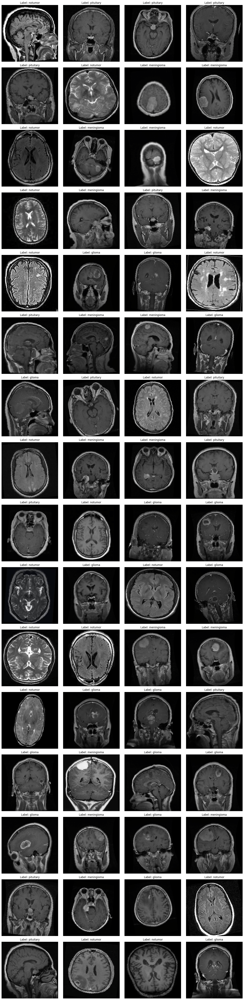

Train samples: 5712
Validation samples: 655
Test samples: 656


In [2]:

# Reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# Paths
train_dir = '/kaggle/input/brain-tumor-mri-dataset/Training'
test_dir  = '/kaggle/input/brain-tumor-mri-dataset/Testing'

# Transforms
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Datasets
train_dataset = ImageFolder(train_dir, transform=train_transforms)
full_val_dataset = ImageFolder(test_dir, transform=eval_transforms)

# Split full_val_dataset into validation and test
val_size = len(full_val_dataset) // 2
test_size = len(full_val_dataset) - val_size
val_dataset, test_dataset = random_split(
    full_val_dataset,
    [val_size, test_size],
    generator=torch.Generator().manual_seed(seed)
)

# DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# Visualize one batch from train_loader (denormalized)
data_iter = iter(train_loader)
images, labels = next(data_iter)  # images: tensor (B, C, H, W)

# Move to CPU and convert to numpy
images_np = images.cpu().numpy().transpose((0, 2, 3, 1))  # (B, H, W, C)

# Denormalize
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
images_np = images_np * std + mean
images_np = np.clip(images_np, 0, 1)

# Create grid and plot
num_images = images_np.shape[0]
cols = 4
rows = int(np.ceil(num_images / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = np.atleast_2d(axes)

for i, ax in enumerate(axes.flat):
    if i < num_images:
        ax.imshow(images_np[i])
        ax.set_title(f'Label: {train_dataset.classes[labels[i]]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

# Print dataset sizes
print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")


/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

✅ All libraries imported successfully!
✅ CONFIG loaded
   Model : DepthWiseMamba-Pico
   Epochs: 50
   Optim : Adam  lr=0.0001
   Sched : None
   W&B   : OFF
✅ DSMaT architecture defined
🏗️  DepthWiseMamba-Pico | Params: 837,359 (0.84M)
✅ Training utilities defined

✅ Found existing model: /kaggle/working/DepthWiseMamba-Pico3_best.pth
   Loaded! Best Val Acc: 93.44% (Epoch 45)


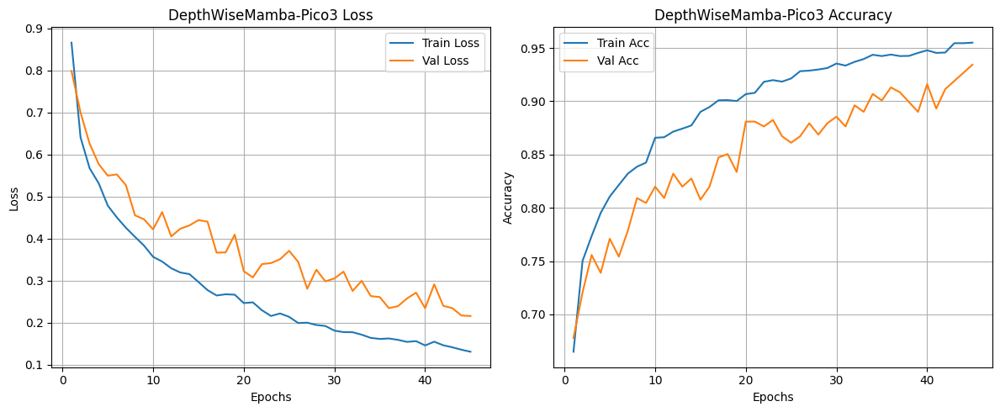

  TEST EVALUATION: DepthWiseMamba-Pico3 | Test Acc: 94.82%
              precision    recall  f1-score   support

      glioma       0.97      0.90      0.93       147
  meningioma       0.90      0.92      0.91       149
     notumor       0.96      0.98      0.97       210
   pituitary       0.97      0.99      0.98       150

    accuracy                           0.95       656
   macro avg       0.95      0.95      0.95       656
weighted avg       0.95      0.95      0.95       656



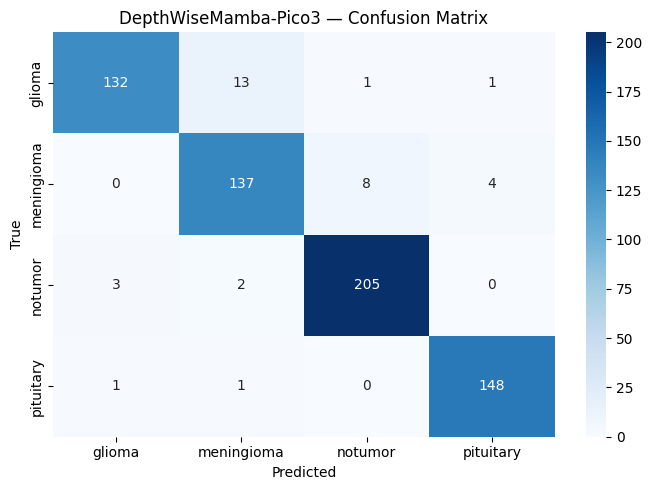

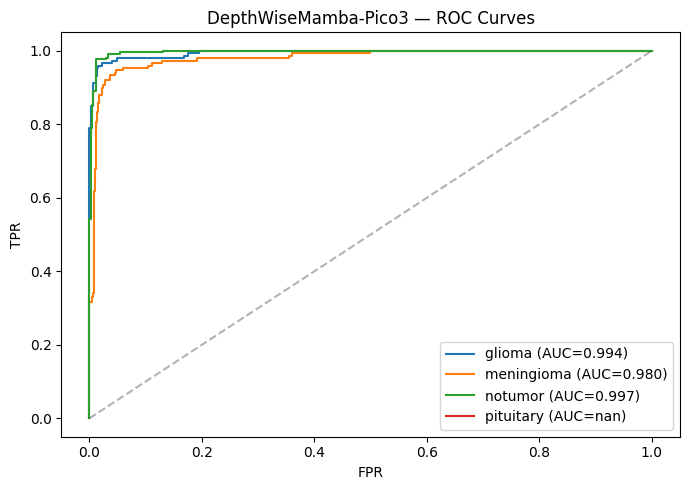


🏆 DepthWiseMamba-Pico3 | Test Acc: 94.82% | Saved: /kaggle/working/DepthWiseMamba-Pico3_best.pth
✅ Done!


In [3]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  SECTION 2 — CONFIG + MODELS + TRAINING + EVALUATION                       ║
# ║  Everything is driven by the single CONFIG dict below.                     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ═══════════════════════════════════════════════════════════════════════════════
# 2.1  UNIFIED EXPERIMENT CONFIG
# ═══════════════════════════════════════════════════════════════════════════════

CONFIG = {
    # ── Data ──────────────────────────────────────────────────────────────────

    # ── Model Selection ──────────────────────────────────────────────────────
    #   Pick ONE: "DepthWiseMamba-Pico" | "DepthwiseMamba-Nano"
    "model_name": "DepthWiseMamba-Pico",

    # ── Model Architecture Hyperparameters ───────────────────────────────────
    "model": {
        "DepthWiseMamba-Pico": {
            "stem_channels":  (16, 32),
            "stage_channels": (48, 96, 128, 192),
            "stage_depths":   (1, 1, 2, 2),
            "sa_heads":       (4, 4),
            "mlp_expand":     2,
            "dropout":        0.2,
        },
        "DepthwiseMamba-Nano": {
            "stem_channels":  (24, 48),
            "stage_channels": (64, 128, 192, 256),
            "stage_depths":   (1, 2, 2, 2),
            "sa_heads":       (4, 4),
            "mlp_expand":     3,
            "dropout":        0.4,
        },
    },

    # ── Training ─────────────────────────────────────────────────────────────
    "epochs": 50,
    "optimizer": "Adam",           # "AdamW" | "Adam" | "SGD"
    "optimizer_params": {
        "lr":           1e-4,
        "weight_decay": 1e-3,
    },
    "scheduler": None,   # "CosineAnnealingLR" | "StepLR" | "ReduceLROnPlateau" | None
    "scheduler_params": {},              # extra kwargs forwarded to the scheduler
    "grad_clip_max_norm": 1.0,

    # ── W&B ──────────────────────────────────────────────────────────────────
    "wandb_project": "DSMaT-BrainTumor",
    "wandb_enabled": False,
}

print("✅ CONFIG loaded")
print(f"   Model : {CONFIG['model_name']}")
print(f"   Epochs: {CONFIG['epochs']}")
print(f"   Optim : {CONFIG['optimizer']}  lr={CONFIG['optimizer_params']['lr']}")
print(f"   Sched : {CONFIG['scheduler']}")
print(f"   W&B   : {'ON' if CONFIG['wandb_enabled'] else 'OFF'}")

# # ═══════════════════════════════════════════════════════════════════════════════
# # 2.2  DATALOADERS  (uses CONFIG["batch_size"])
# # ═══════════════════════════════════════════════════════════════════════════════

# train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"],
#                           shuffle=True,  num_workers=CONFIG["num_workers"], pin_memory=True)
# val_loader   = DataLoader(val_dataset,   batch_size=CONFIG["batch_size"],
#                           shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)
# test_loader  = DataLoader(test_dataset,  batch_size=CONFIG["batch_size"],
#                           shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)

# print(f"\n📦 Train loader: {len(train_dataset)} samples, {len(train_loader)} batches")
# print(f"📦 Val loader:   {len(val_dataset)} samples, {len(val_loader)} batches")
# print(f"📦 Test loader:  {len(test_dataset)} samples, {len(test_loader)} batches")

# ═══════════════════════════════════════════════════════════════════════════════
# 2.3  MODEL ARCHITECTURE
# ═══════════════════════════════════════════════════════════════════════════════

# ── Building Blocks ──────────────────────────────────────────────────────────

class DSConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, kernel_size, stride, padding, groups=in_ch, bias=False)
        self.pw = nn.Conv2d(in_ch, out_ch, 1, bias=bias)
    def forward(self, x):
        return self.pw(self.dw(x))

class DSConvStem(nn.Module):
    def __init__(self, in_ch=3, mid_ch=32, out_ch=64):
        super().__init__()
        self.stem = nn.Sequential(
            DSConv2d(in_ch, mid_ch, 3, stride=2, padding=1),
            nn.BatchNorm2d(mid_ch), nn.GELU(),
            DSConv2d(mid_ch, out_ch, 3, stride=2, padding=1),
            nn.BatchNorm2d(out_ch), nn.GELU(),
        )
    def forward(self, x):
        return self.stem(x)

class DSConvResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            DSConv2d(channels, channels, 3, 1, 1),
            nn.BatchNorm2d(channels), nn.GELU(),
            DSConv2d(channels, channels, 3, 1, 1),
            nn.BatchNorm2d(channels),
        )
    def forward(self, x):
        return self.block(x) + x

class DSConvDownsample(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.down = nn.Sequential(
            DSConv2d(in_ch, out_ch, 3, stride=2, padding=1),
            nn.BatchNorm2d(out_ch),
        )
    def forward(self, x):
        return self.down(x)

# ── Mamba / Attention / MLP ──────────────────────────────────────────────────

class SelectiveScan(nn.Module):
    def __init__(self, d_inner, d_state=16):
        super().__init__()
        self.d_state = d_state
        self.dt_rank = max(1, d_inner // 16)
        self.x_proj  = nn.Linear(d_inner, self.dt_rank + 2 * d_state, bias=False)
        self.dt_proj = nn.Linear(self.dt_rank, d_inner, bias=True)
        A = torch.arange(1, d_state + 1, dtype=torch.float32).unsqueeze(0).expand(d_inner, -1)
        self.A_log = nn.Parameter(torch.log(A))
        self.D     = nn.Parameter(torch.ones(d_inner))

    def forward(self, x):
        B_batch, D, L = x.shape
        x_seq = x.transpose(1, 2)
        x_dbl = self.x_proj(x_seq)
        dt_raw, B_param, C_param = x_dbl.split(
            [self.dt_rank, self.d_state, self.d_state], dim=-1)
        dt = F.softplus(self.dt_proj(dt_raw))
        A  = -torch.exp(self.A_log)
        dA  = torch.exp(dt.unsqueeze(-1) * A)
        dBx = dt.unsqueeze(-1) * B_param.unsqueeze(2)
        h = torch.zeros(B_batch, D, self.d_state, device=x.device, dtype=x.dtype)
        ys = []
        for t in range(L):
            h = dA[:, t] * h + dBx[:, t] * x_seq[:, t, :, None]
            yt = (h * C_param[:, t, None, :]).sum(-1)
            ys.append(yt)
        y = torch.stack(ys, dim=2)
        return y + self.D.unsqueeze(0).unsqueeze(-1) * x

class MambaVisionMixer(nn.Module):
    def __init__(self, dim, d_state=16, kernel_size=3):
        super().__init__()
        half = dim // 2
        self.proj_x   = nn.Linear(dim, half, bias=False)
        self.conv1d_x = nn.Conv1d(half, half, kernel_size, padding='same', groups=half)
        self.ssm      = SelectiveScan(half, d_state)
        self.proj_z   = nn.Linear(dim, half, bias=False)
        self.conv1d_z = nn.Conv1d(half, half, kernel_size, padding='same', groups=half)
        self.out_proj = nn.Linear(dim, dim)
        self.norm     = nn.LayerNorm(dim)

    def forward(self, x):
        residual = x
        x = self.norm(x)
        x1 = self.proj_x(x).transpose(1, 2)
        x1 = F.silu(self.conv1d_x(x1))
        x1 = self.ssm(x1)
        x2 = self.proj_z(x).transpose(1, 2)
        x2 = F.silu(self.conv1d_z(x2))
        out = torch.cat([x1, x2], dim=1).transpose(1, 2)
        return self.out_proj(out) + residual

class SelfAttentionBlock(nn.Module):
    def __init__(self, dim, num_heads=4, dropout=0.1):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
    def forward(self, x):
        normed = self.norm(x)
        out, _ = self.attn(normed, normed, normed)
        return out + x

class MLPBlock(nn.Module):
    def __init__(self, dim, expand=4, dropout=0.1):
        super().__init__()
        hidden = dim * expand
        self.net = nn.Sequential(
            nn.LayerNorm(dim), nn.Linear(dim, hidden), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(hidden, dim), nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x) + x

class MambaVisionLayer(nn.Module):
    def __init__(self, dim, mixer_type='mamba', num_heads=4,
                 d_state=16, mlp_expand=4, dropout=0.1):
        super().__init__()
        if mixer_type == 'mamba':
            self.mixer = MambaVisionMixer(dim, d_state=d_state)
        else:
            self.mixer = SelfAttentionBlock(dim, num_heads=num_heads, dropout=dropout)
        self.mlp = MLPBlock(dim, expand=mlp_expand, dropout=dropout)
    def forward(self, x):
        return self.mlp(self.mixer(x))

# ── DSMaT Full Model ─────────────────────────────────────────────────────────

class DSMaT(nn.Module):
    def __init__(self, stem_channels=(32, 64), stage_channels=(96, 192, 256, 384),
                 stage_depths=(2, 2, 4, 4), sa_heads=(4, 8), d_state=16,
                 mlp_expand=4, num_classes=4, dropout=0.2):
        super().__init__()
        stem_mid, stem_out = stem_channels
        self.stem = DSConvStem(3, stem_mid, stem_out)

        self.down1  = DSConvDownsample(stem_out, stage_channels[0])
        self.stage1 = nn.Sequential(*[DSConvResBlock(stage_channels[0])
                                      for _ in range(stage_depths[0])])

        self.down2  = DSConvDownsample(stage_channels[0], stage_channels[1])
        self.stage2 = nn.Sequential(*[DSConvResBlock(stage_channels[1])
                                      for _ in range(stage_depths[1])])

        self.down3 = DSConvDownsample(stage_channels[1], stage_channels[2])
        n3 = stage_depths[2]; n3m = n3 // 2; n3a = n3 - n3m
        s3 = []
        for _ in range(n3m):
            s3.append(MambaVisionLayer(stage_channels[2], 'mamba',
                      d_state=d_state, mlp_expand=mlp_expand, dropout=dropout))
        for _ in range(n3a):
            s3.append(MambaVisionLayer(stage_channels[2], 'attention',
                      num_heads=sa_heads[0], mlp_expand=mlp_expand, dropout=dropout))
        self.stage3 = nn.ModuleList(s3)

        self.down4 = DSConvDownsample(stage_channels[2], stage_channels[3])
        n4 = stage_depths[3]; n4m = n4 // 2; n4a = n4 - n4m
        s4 = []
        for _ in range(n4m):
            s4.append(MambaVisionLayer(stage_channels[3], 'mamba',
                      d_state=d_state, mlp_expand=mlp_expand, dropout=dropout))
        for _ in range(n4a):
            s4.append(MambaVisionLayer(stage_channels[3], 'attention',
                      num_heads=sa_heads[1], mlp_expand=mlp_expand, dropout=dropout))
        self.stage4 = nn.ModuleList(s4)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.LayerNorm(stage_channels[3]),
            nn.Dropout(dropout),
            nn.Linear(stage_channels[3], num_classes),
        )

    def forward(self, x):
        B = x.shape[0]
        x = self.stem(x)
        x = self.down1(x); x = self.stage1(x)
        x = self.down2(x); x = self.stage2(x)
        x = self.down3(x)
        B3, C3, H3, W3 = x.shape
        x = x.flatten(2).transpose(1, 2)
        for layer in self.stage3:
            x = layer(x)
        x = x.transpose(1, 2).reshape(B, C3, H3, W3)
        x = self.down4(x)
        B4, C4, H4, W4 = x.shape
        x = x.flatten(2).transpose(1, 2)
        for layer in self.stage4:
            x = layer(x)
        x = x.transpose(1, 2).reshape(B, C4, H4, W4)
        x = self.pool(x).flatten(1)
        return self.head(x)

print("✅ DSMaT architecture defined")

# ── Build model from CONFIG ──────────────────────────────────────────────────
NUM_CLASSES = 4
def build_model(config):
    """Instantiate the selected model variant from CONFIG."""
    name = config["model_name"]
    arch = config["model"][name]
    model = DSMaT(num_classes=NUM_CLASSES, **arch).to(DEVICE)
    return model

model = build_model(CONFIG)
n_params = sum(p.numel() for p in model.parameters())
print(f"🏗️  {CONFIG['model_name']} | Params: {n_params:,} ({n_params/1e6:.2f}M)")

# ═══════════════════════════════════════════════════════════════════════════════
# 2.4  TRAINING & EVALUATION UTILITIES
# ═══════════════════════════════════════════════════════════════════════════════

def _build_optimizer(model, config):
    """Build an optimizer from CONFIG."""
    name   = config["optimizer"]
    params = config["optimizer_params"]
    if name == "AdamW":
        return optim.AdamW(model.parameters(), **params)
    elif name == "Adam":
        return optim.Adam(model.parameters(), **params)
    elif name == "SGD":
        return optim.SGD(model.parameters(), momentum=params.get("momentum", 0.9),
                         lr=params["lr"], weight_decay=params.get("weight_decay", 0))
    else:
        raise ValueError(f"Unknown optimizer: {name}")

def _build_scheduler(optimizer, config):
    """Build a LR scheduler from CONFIG (returns None if disabled)."""
    name = config["scheduler"]
    if name is None or name == "None":
        return None
    extra = config.get("scheduler_params", {})
    if name == "CosineAnnealingLR":
        return optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=config["epochs"], **extra)
    elif name == "StepLR":
        return optim.lr_scheduler.StepLR(
            optimizer, step_size=extra.get("step_size", 10),
            gamma=extra.get("gamma", 0.1))
    elif name == "ReduceLROnPlateau":
        return optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', patience=extra.get("patience", 5),
            factor=extra.get("factor", 0.5))
    else:
        raise ValueError(f"Unknown scheduler: {name}")

from torch.cuda.amp import autocast, GradScaler

# Assumes model, train_loader, val_loader, CONFIG, _build_optimizer, _build_scheduler,
# plot_history, DEVICE are defined elsewhere in your script.

def train_one_epoch(model, loader, optimizer, criterion, device, grad_clip, scaler):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        # Scale loss, backprop, unscale for gradient clipping, step optimizer, update scaler
        scaler.scale(loss).backward()

        # Unscale before clipping
        scaler.unscale_(optimizer)
        if grad_clip is not None and grad_clip > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)

        scaler.step(optimizer)
        scaler.update()

        loss_sum += loss.item() * labels.size(0)
        correct  += (outputs.argmax(1) == labels).sum().item()
        total    += labels.size(0)

    return loss_sum / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss_sum += loss.item() * labels.size(0)
        probs = F.softmax(outputs, dim=1)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return (loss_sum / total, correct / total,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))

def plot_history(history, model_name="Model"):
    if not history or not history.get('train_loss'):
        print("⚠️ No history data to plot."); return
    epochs_range = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.plot(epochs_range, history['train_loss'], label='Train Loss')
    ax1.plot(epochs_range, history['val_loss'],   label='Val Loss')
    ax1.set(title=f'{model_name} Loss', xlabel='Epochs', ylabel='Loss')
    ax1.legend(); ax1.grid(True)
    ax2.plot(epochs_range, history['train_acc'], label='Train Acc')
    ax2.plot(epochs_range, history['val_acc'],   label='Val Acc')
    ax2.set(title=f'{model_name} Accuracy', xlabel='Epochs', ylabel='Accuracy')
    ax2.legend(); ax2.grid(True)
    plt.tight_layout(); plt.show()
    return fig

print("✅ Training utilities defined")

# ═══════════════════════════════════════════════════════════════════════════════
# 2.5  W&B INIT + TRAINING LOOP
# ═══════════════════════════════════════════════════════════════════════════════

# ── Initialise W&B ───────────────────────────────────────────────────────────
if CONFIG["wandb_enabled"]:
    from kaggle_secrets import UserSecretsClient
    wandb.login(key=UserSecretsClient().get_secret("WANDB_API_KEY"))
    wandb.init(
        project=CONFIG["wandb_project"],
        name=CONFIG["model_name"],
        config=CONFIG,
    )
    print("✅ W&B run initialised")

# ── Training ─────────────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = _build_optimizer(model, CONFIG)
scheduler = _build_scheduler(optimizer, CONFIG)
SAVE_DIR='/kaggle/working/'
history   = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
model_name   = CONFIG["model_name"] + "3"
save_path    = os.path.join(SAVE_DIR, f'{model_name}_best.pth')

# ── Check for existing checkpoint ────────────────────────────────────────────
FORCE_RETRAIN = False   # flip to True to retrain from scratch
# Mixed precision scaler
scaler = GradScaler()

if os.path.exists(save_path) and not FORCE_RETRAIN:
    print(f"\n✅ Found existing model: {save_path}")
    checkpoint = torch.load(save_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    scaler_state = checkpoint.get('scaler_state_dict', None)
    if scaler_state is not None:
        scaler.load_state_dict(scaler_state)
    history      = checkpoint.get('history', {})
    best_val_acc = checkpoint.get('val_acc', 0.0)
    best_epoch   = checkpoint.get('epoch', '?')
    print(f"   Loaded! Best Val Acc: {best_val_acc*100:.2f}% (Epoch {best_epoch})")
    plot_history(history, model_name)
else:
    print(f"\n🚀 Starting training for {model_name}...")
    for epoch in range(CONFIG["epochs"]):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, DEVICE,
            CONFIG["grad_clip_max_norm"],scaler)
        val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion, DEVICE)

        # Scheduler step
        if scheduler is not None:
            if CONFIG["scheduler"] == "ReduceLROnPlateau":
                scheduler.step(val_loss)
            else:
                scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # ── W&B per-epoch logging ────────────────────────────────────────────
        if CONFIG["wandb_enabled"]:
            wandb.log({
                "epoch":      epoch + 1,
                "train_loss": tr_loss,
                "train_acc":  tr_acc,
                "val_loss":   val_loss,
                "val_acc":    val_acc,
                "lr":         optimizer.param_groups[0]['lr'],
            })

        # Save best
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch':                epoch + 1,
                'model_state_dict':     model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scaler_state_dict': scaler.state_dict(),
                'val_acc':              val_acc,
                'val_loss':             val_loss,
                'model_name':           model_name,
                'history':              history,
            }, save_path)
            marker = ' ★ saved'
        else:
            marker = ''

        print(f"  Ep {epoch+1:3d}/{CONFIG['epochs']} | "
              f"Tr {tr_loss:.4f}/{tr_acc:.4f} | "
              f"Val {val_loss:.4f}/{val_acc:.4f} | "
              f"{time.time()-t0:.1f}s{marker}")

    # Reload best
    checkpoint = torch.load(save_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"\n  💾 Best model loaded: Epoch {checkpoint['epoch']} | "
          f"Val Acc: {checkpoint['val_acc']*100:.2f}%")
    plot_history(history, model_name)

# ═══════════════════════════════════════════════════════════════════════════════
# 2.6  TEST-SET EVALUATION + W&B FINAL METRICS
# ═══════════════════════════════════════════════════════════════════════════════

test_loss, test_acc, test_preds, test_labels, test_probs = evaluate(
    model, test_loader, criterion, DEVICE)

print("=" * 70)
print(f"  TEST EVALUATION: {model_name} | Test Acc: {test_acc*100:.2f}%")
print("=" * 70)

class_names = train_dataset.classes
report_str = classification_report(test_labels, test_preds, target_names=class_names)
print(report_str)

# ── Confusion Matrix ─────────────────────────────────────────────────────────
fig_cm, ax_cm = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax_cm)
ax_cm.set_title(f'{model_name} — Confusion Matrix')
ax_cm.set_xlabel('Predicted'); ax_cm.set_ylabel('True')
plt.tight_layout()
plt.savefig(f'confusion_matrix_{model_name}.png', dpi=150, bbox_inches='tight')
plt.show()

# ── ROC Curves ───────────────────────────────────────────────────────────────
fig_roc, ax_roc = plt.subplots(figsize=(7, 5))
y_bin = label_binarize(test_labels, classes=[0, 1, 2,4])
for cls_i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_bin[:, cls_i], test_probs[:, cls_i])
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, label=f'{class_names[cls_i]} (AUC={roc_auc:.3f})')
ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax_roc.set(title=f'{model_name} — ROC Curves', xlabel='FPR', ylabel='TPR')
ax_roc.legend()
plt.tight_layout()
plt.savefig(f'roc_curves_{model_name}.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-class metrics ────────────────────────────────────────────────────────
per_class_acc  = [accuracy_score(test_labels[test_labels == c], test_preds[test_labels == c])
                  for c in range(NUM_CLASSES)]
per_class_prec = precision_score(test_labels, test_preds, average=None)
per_class_rec  = recall_score(test_labels, test_preds, average=None)
per_class_f1   = f1_score(test_labels, test_preds, average=None)

# ── W&B final logging ────────────────────────────────────────────────────────
if CONFIG["wandb_enabled"]:
    # Final scalar metrics
    wandb.log({
        "test_loss": test_loss,
        "test_acc":  test_acc,
        "test_f1_macro": f1_score(test_labels, test_preds, average='macro'),
    })

    # Confusion matrix image
    wandb.log({"confusion_matrix": wandb.Image(fig_cm)})

    # ROC curves image
    wandb.log({"roc_curves": wandb.Image(fig_roc)})

    # Per-class metrics table
    metrics_table = wandb.Table(
        columns=["Class", "Accuracy", "Precision", "Recall", "F1"],
        data=[[class_labels[c], per_class_acc[c], per_class_prec[c],
               per_class_rec[c], per_class_f1[c]]
              for c in range(NUM_CLASSES)]
    )
    wandb.log({"per_class_metrics": metrics_table})

    wandb.finish()
    print("\n✅ W&B run finished — config, metrics, and evaluation logged.")

print(f"\n🏆 {model_name} | Test Acc: {test_acc*100:.2f}% | Saved: {save_path}")
print("✅ Done!")

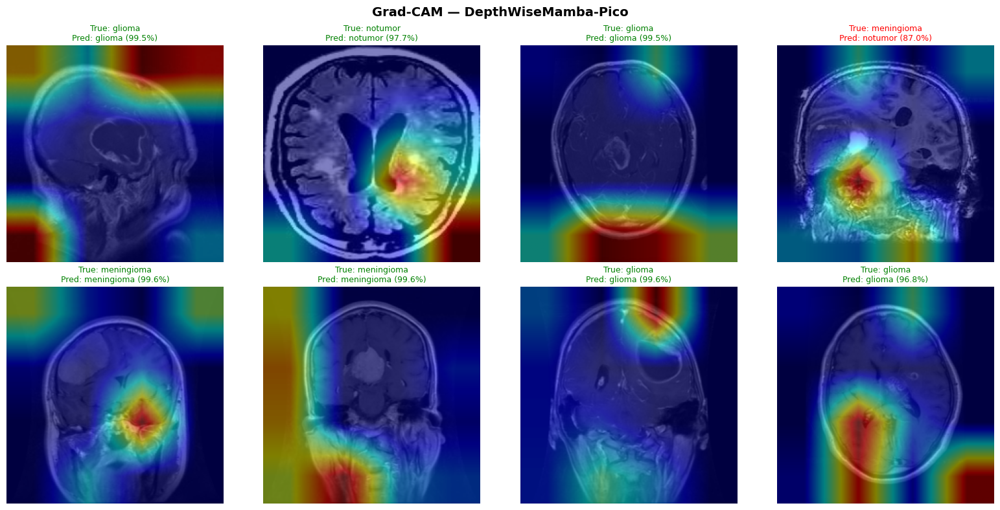

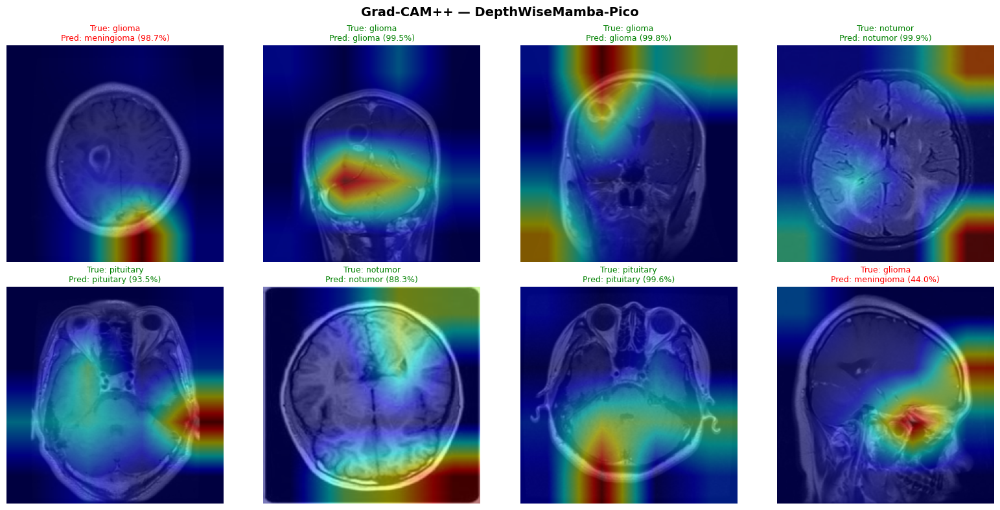

✅ Explainability visualizations done!


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2.7  EXPLAINABILITY — Grad-CAM & Grad-CAM++
# ═══════════════════════════════════════════════════════════════════════════════

# ── Grad-CAM Engine ──────────────────────────────────────────────────────────
import cv2
class GradCAM:
    """
    Grad-CAM for DSMaT.
    Hooks into model.pool so the *input* to the global-average-pool
    is the last spatial feature map (after stage-4 reshape).
    """
    def __init__(self, model, target_layer=None, grad_cam_pp=False):
        self.model = model
        self.grad_cam_pp = grad_cam_pp
        self.target_layer = target_layer or model.pool  # default: just before GAP
        self.activations = None
        self.gradients   = None

        # Register hooks
        self._fwd_hook = self.target_layer.register_forward_hook(self._save_activation)
        self._bwd_hook = self.target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        # We want the INPUT to pool (the spatial feature map), not the output
        self.activations = inp[0].detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_input[0].detach()

    def generate(self, input_tensor, target_class=None):
        self.model.eval()
        output = self.model(input_tensor)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0, target_class] = 1.0
        output.backward(gradient=one_hot, retain_graph=True)

        acts  = self.activations  # (1, C, H, W)
        grads = self.gradients    # (1, C, H, W)

        if self.grad_cam_pp:
            # Grad-CAM++ weights
            grads_pow2 = grads ** 2
            grads_pow3 = grads ** 3
            sum_acts   = acts.sum(dim=(2, 3), keepdim=True)
            denom      = 2.0 * grads_pow2 + sum_acts * grads_pow3 + 1e-8
            alpha      = grads_pow2 / denom
            weights    = (alpha * F.relu(grads)).sum(dim=(2, 3), keepdim=True)
        else:
            # Standard Grad-CAM weights
            weights = grads.mean(dim=(2, 3), keepdim=True)

        cam = (weights * acts).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=input_tensor.shape[2:],
                            mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()

        # Normalize to [0, 1]
        cam_min, cam_max = cam.min(), cam.max()
        if cam_max - cam_min > 1e-8:
            cam = (cam - cam_min) / (cam_max - cam_min)
        else:
            cam = np.zeros_like(cam)

        pred_prob = F.softmax(output, dim=1)[0, target_class].item()
        return cam, target_class, pred_prob

    def remove_hooks(self):
        self._fwd_hook.remove()
        self._bwd_hook.remove()


def overlay_cam_on_image(img_np, cam, alpha=0.5, colormap=cv2.COLORMAP_JET):
    """Overlay a CAM heatmap on an RGB image (H,W,3 float [0,1])."""
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), colormap)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    blended = alpha * heatmap + (1 - alpha) * img_np
    return np.clip(blended, 0, 1)


# ── Visualise Grad-CAM for a batch of test images ───────────────────────────

def visualize_gradcam(model, dataloader, class_names, device,
                      num_images=8, grad_cam_pp=False):
    """
    Show Grad-CAM overlays for `num_images` randomly-sampled test images.
    """
    tag = "Grad-CAM++" if grad_cam_pp else "Grad-CAM"
    gcam = GradCAM(model, grad_cam_pp=grad_cam_pp)

    # Gather all images + labels from loader
    all_imgs, all_lbls = [], []
    for imgs, lbls in dataloader:
        all_imgs.append(imgs); all_lbls.append(lbls)
    all_imgs = torch.cat(all_imgs)
    all_lbls = torch.cat(all_lbls)

    # Random sample
    idxs = random.sample(range(len(all_imgs)), min(num_images, len(all_imgs)))

    cols = 4
    rows = (len(idxs) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = axes.flatten() if rows * cols > 1 else [axes]

    # ImageNet-style denorm (common for MRI preprocessed with torchvision)
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    for i, idx in enumerate(idxs):
        img_tensor = all_imgs[idx].unsqueeze(0).to(device)
        true_label = all_lbls[idx].item()

        cam, pred_cls, pred_prob = gcam.generate(img_tensor)

        # Denormalise for display
        img_np = all_imgs[idx].permute(1, 2, 0).cpu().numpy()
        img_np = std * img_np + mean
        img_np = np.clip(img_np, 0, 1)

        overlay = overlay_cam_on_image(img_np, cam, alpha=0.5)

        ax = axes[i]
        ax.imshow(overlay)
        true_name = class_names[true_label]
        pred_name = class_names[pred_cls]
        color = "green" if pred_cls == true_label else "red"
        ax.set_title(f"True: {true_name}\nPred: {pred_name} ({pred_prob:.1%})",
                     fontsize=9, color=color)
        ax.axis('off')

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f"{tag} — {CONFIG['model_name']}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{tag.lower().replace("+","p")}_{model_name}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    gcam.remove_hooks()
    return fig


# ── Run both Grad-CAM and Grad-CAM++ ────────────────────────────────────────
# ✅ Fixed — just remove "model=" since it's the first positional arg
fig_gc   = visualize_gradcam(model, test_loader, class_names, DEVICE,
                              num_images=8, grad_cam_pp=False)
fig_gcpp = visualize_gradcam(model, test_loader, class_names, DEVICE,
                              num_images=8, grad_cam_pp=True)
# ── W&B log (if enabled) ────────────────────────────────────────────────────
if CONFIG["wandb_enabled"]:
    wandb.log({
        "gradcam":      wandb.Image(fig_gc),
        "gradcam_pp":   wandb.Image(fig_gcpp),
    })

print("✅ Explainability visualizations done!")

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1: Clear ALL old hooks from the model
# ═══════════════════════════════════════════════════════════════════════════════
for layer in list(model.stage3) + list(model.stage4):
    if hasattr(layer, 'mixer') and isinstance(layer.mixer, SelfAttentionBlock):
        layer.mixer.attn._forward_hooks.clear()
        layer.mixer.attn._backward_hooks.clear()
print("🧹 All old hooks cleared!")

🧹 All old hooks cleared!



🔍 Per-head Self-Attention Maps...


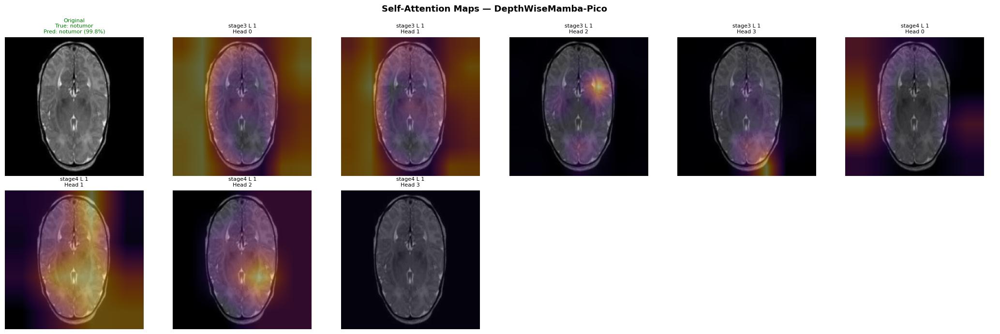

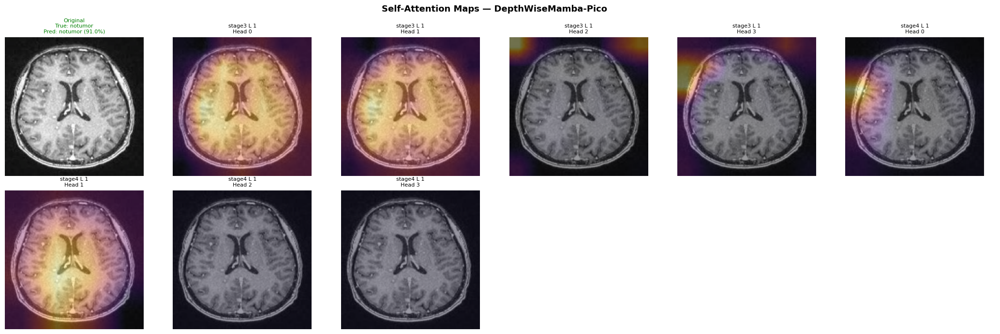

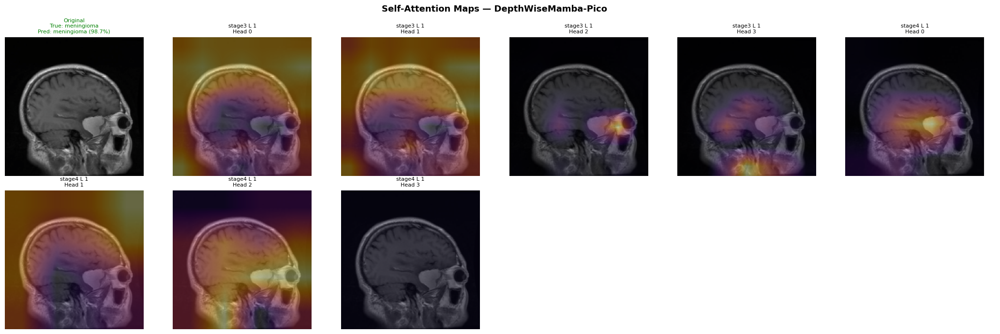

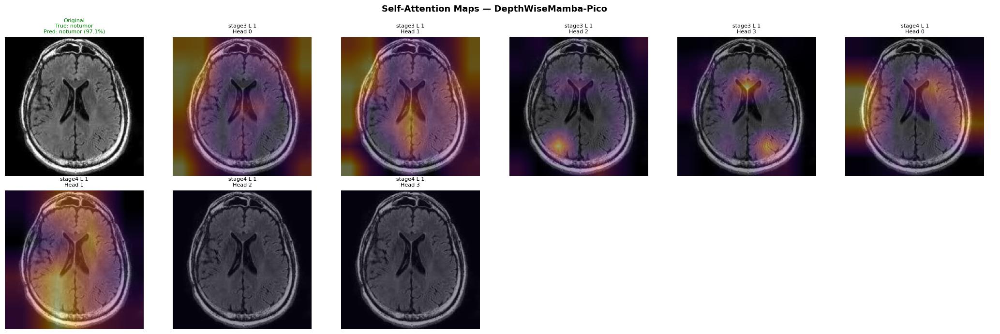

✅ Attention map visualization done!

🔍 Attention Rollout (aggregated across layers)...


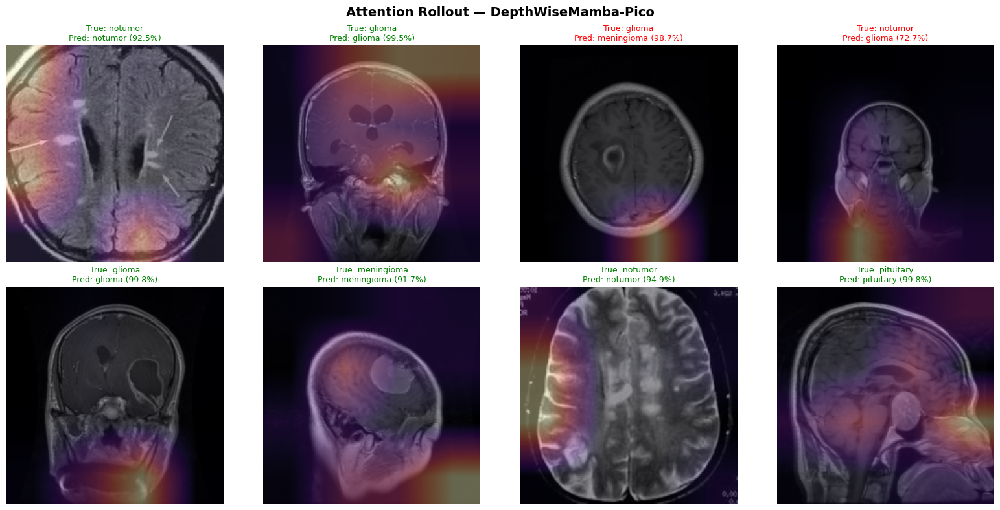

✅ Done!


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 2: Attention Map Visualization (hook-free approach)
# ═══════════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def extract_attention_maps(model, input_tensor, device):
    """
    Manually run the forward pass step-by-step to capture
    attention weights WITHOUT hooks (avoids recursion entirely).
    """
    model.eval()
    x = input_tensor.to(device)
    B = x.shape[0]

    # Stem + Stage 1-2 (conv only, no attention)
    x = model.stem(x)
    x = model.down1(x); x = model.stage1(x)
    x = model.down2(x); x = model.stage2(x)

    # Stage 3
    x = model.down3(x)
    B3, C3, H3, W3 = x.shape
    x = x.flatten(2).transpose(1, 2)

    attn_maps = {}
    for i, layer in enumerate(model.stage3):
        if isinstance(layer.mixer, SelfAttentionBlock):
            normed = layer.mixer.norm(x)
            attn_out, attn_weights = layer.mixer.attn(
                normed, normed, normed,
                need_weights=True, average_attn_weights=False
            )
            x = attn_out + x
            x = layer.mlp(x)
            attn_maps[f"stage3_attn_{i}"] = attn_weights.detach().cpu()
        else:
            x = layer(x)

    x = x.transpose(1, 2).reshape(B, C3, H3, W3)

    # Stage 4
    x = model.down4(x)
    B4, C4, H4, W4 = x.shape
    x = x.flatten(2).transpose(1, 2)

    for i, layer in enumerate(model.stage4):
        if isinstance(layer.mixer, SelfAttentionBlock):
            normed = layer.mixer.norm(x)
            attn_out, attn_weights = layer.mixer.attn(
                normed, normed, normed,
                need_weights=True, average_attn_weights=False
            )
            x = attn_out + x
            x = layer.mlp(x)
            attn_maps[f"stage4_attn_{i}"] = attn_weights.detach().cpu()
        else:
            x = layer(x)

    x = x.transpose(1, 2).reshape(B, C4, H4, W4)
    x = model.pool(x).flatten(1)
    output = model.head(x)

    pred_class = output.argmax(dim=1).item()
    pred_prob = F.softmax(output, dim=1)[0, pred_class].item()
    return attn_maps, pred_class, pred_prob


def visualize_attention_maps(model, dataloader, class_names, device, num_images=4):
    all_imgs, all_lbls = [], []
    for imgs, lbls in dataloader:
        all_imgs.append(imgs); all_lbls.append(lbls)
    all_imgs = torch.cat(all_imgs)
    all_lbls = torch.cat(all_lbls)

    idxs = random.sample(range(len(all_imgs)), min(num_images, len(all_imgs)))

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    for idx in idxs:
        img_tensor = all_imgs[idx].unsqueeze(0).to(device)
        true_label = all_lbls[idx].item()

        attn_maps, pred_cls, pred_prob = extract_attention_maps(model, img_tensor, device)

        if not attn_maps:
            print("⚠️ No attention maps captured.")
            continue

        img_np = all_imgs[idx].permute(1, 2, 0).cpu().numpy()
        img_np = std * img_np + mean
        img_np = np.clip(img_np, 0, 1)

        layer_names = sorted(attn_maps.keys())
        total_heads = sum(attn_maps[ln].shape[1] for ln in layer_names)

        cols = min(total_heads + 1, 6)
        rows = (total_heads + 1 + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(3.5 * cols, 3.5 * rows))
        axes = np.array(axes).flatten()

        axes[0].imshow(img_np)
        true_name = class_names[true_label]
        pred_name = class_names[pred_cls]
        color = "green" if pred_cls == true_label else "red"
        axes[0].set_title(f"Original\nTrue: {true_name}\nPred: {pred_name} ({pred_prob:.1%})",
                          fontsize=8, color=color)
        axes[0].axis('off')

        ax_idx = 1
        for ln in layer_names:
            attn = attn_maps[ln]  # (1, num_heads, N, N)
            num_heads = attn.shape[1]
            N = attn.shape[2]
            H_feat = W_feat = int(math.sqrt(N))

            for head in range(num_heads):
                if ax_idx >= len(axes):
                    break
                head_attn = attn[0, head].numpy()
                attn_received = head_attn.mean(axis=0)
                attn_2d = attn_received.reshape(H_feat, W_feat)

                a_min, a_max = attn_2d.min(), attn_2d.max()
                if a_max - a_min > 1e-8:
                    attn_2d = (attn_2d - a_min) / (a_max - a_min)

                attn_resized = cv2.resize(attn_2d, (img_np.shape[1], img_np.shape[0]),
                                          interpolation=cv2.INTER_LINEAR)

                heatmap = cv2.applyColorMap(np.uint8(255 * attn_resized), cv2.COLORMAP_INFERNO)
                heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
                overlay = 0.4 * heatmap + 0.6 * img_np

                axes[ax_idx].imshow(np.clip(overlay, 0, 1))
                stage_label = ln.replace("_", " ").replace("attn", "L")
                axes[ax_idx].set_title(f"{stage_label}\nHead {head}", fontsize=8)
                axes[ax_idx].axis('off')
                ax_idx += 1

        for j in range(ax_idx, len(axes)):
            axes[j].axis('off')

        fig.suptitle(f"Self-Attention Maps — {CONFIG['model_name']}", fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'attention_maps_{model_name}_{idx}.png', dpi=150, bbox_inches='tight')
        plt.show()

    print("✅ Attention map visualization done!")


def attention_rollout(model, dataloader, class_names, device, num_images=4):
    all_imgs, all_lbls = [], []
    for imgs, lbls in dataloader:
        all_imgs.append(imgs); all_lbls.append(lbls)
    all_imgs = torch.cat(all_imgs)
    all_lbls = torch.cat(all_lbls)

    idxs = random.sample(range(len(all_imgs)), min(num_images, len(all_imgs)))

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    cols = min(num_images, 4)
    rows = (num_images + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).flatten()

    for i, idx in enumerate(idxs):
        img_tensor = all_imgs[idx].unsqueeze(0).to(device)
        true_label = all_lbls[idx].item()

        attn_maps, pred_cls, pred_prob = extract_attention_maps(model, img_tensor, device)
        layer_names = sorted(attn_maps.keys())

        if not layer_names:
            continue

        rollout = None
        for ln in layer_names:
            attn = attn_maps[ln][0]       # (num_heads, N, N)
            attn_avg = attn.mean(dim=0)    # (N, N)
            I = torch.eye(attn_avg.size(0))
            attn_avg = 0.5 * attn_avg + 0.5 * I
            attn_avg = attn_avg / attn_avg.sum(dim=-1, keepdim=True)

            if rollout is None:
                rollout = attn_avg
            elif rollout.shape == attn_avg.shape:
                rollout = torch.matmul(attn_avg, rollout)
            else:
                rollout = attn_avg

        N = rollout.shape[0]
        H_feat = W_feat = int(math.sqrt(N))
        rollout_map = rollout.mean(dim=0).numpy().reshape(H_feat, W_feat)

        r_min, r_max = rollout_map.min(), rollout_map.max()
        if r_max - r_min > 1e-8:
            rollout_map = (rollout_map - r_min) / (r_max - r_min)

        img_np = all_imgs[idx].permute(1, 2, 0).cpu().numpy()
        img_np = std * img_np + mean
        img_np = np.clip(img_np, 0, 1)

        rollout_resized = cv2.resize(rollout_map, (img_np.shape[1], img_np.shape[0]),
                                      interpolation=cv2.INTER_LINEAR)
        heatmap = cv2.applyColorMap(np.uint8(255 * rollout_resized), cv2.COLORMAP_MAGMA)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
        overlay = 0.4 * heatmap + 0.6 * img_np

        axes[i].imshow(np.clip(overlay, 0, 1))
        color = "green" if pred_cls == true_label else "red"
        axes[i].set_title(f"True: {class_names[true_label]}\nPred: {class_names[pred_cls]} ({pred_prob:.1%})",
                          fontsize=9, color=color)
        axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f"Attention Rollout — {CONFIG['model_name']}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'attention_rollout_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return fig


# ── Run ──────────────────────────────────────────────────────────────────────
print("\n🔍 Per-head Self-Attention Maps...")
visualize_attention_maps(model, test_loader, class_names, DEVICE, num_images=4)

print("\n🔍 Attention Rollout (aggregated across layers)...")
fig_rollout = attention_rollout(model, test_loader, class_names, DEVICE, num_images=8)

print("✅ Done!")